# 11 - Valutazione su ASVspoof 2021 DF: ablazione P / Wf / E / PWfE

Valutazione dei modelli gia' addestrati su ASVspoof 2019 LA sulla partizione di valutazione di
ASVspoof 2021 Deepfake. Si estraggono le caratteristiche sui
file del DF, si applicano le trasformazioni salvate in addestramento e si calcolano i punteggi.

**Configurazioni valutate**
- **P**: solo ramo prosodico, variante D (notebook 06.1, `model_D_seed0.pt`);
- **Wf**: solo ramo Whisper a livello di file (notebook 09, `model_Wf_seed0.pt`);
- **E**: solo ramo ECAPA-TDNN (notebook 09, `model_E_seed0.pt`);
- **PWfE**: architettura completa con fusione tardiva (notebook 10, `model_PWfE_seed0.pt`).

Whisper e' usato **solo a livello di file**: i frame non vengono ne' salvati ne' utilizzati.

**Tre fasi, da eseguire in sessioni distinte** (si imposta `FASE` nella cella di configurazione):

1. `"ptm"` - estrazione di `whisper_mean` (512) ed ECAPA (192). 
2. `"prosodia"` - estrazione delle 8 caratteristiche Praat per finestre da 200 ms. Richiede CPU
   multi-core. 
3. `"inferenza"` - carica le caratteristiche prodotte dalle due fasi precedenti, applica i modelli e
   calcola le metriche.

Entrambe le fasi di estrazione scrivono a blocchi e **riprendono da dove si erano fermate**: dopo
un'interruzione basta rieseguire la stessa fase.

**Metrica**: EER con l'implementazione ufficiale ASVspoof 2021 (`eval_metrics.py`, stesso SHA256 dei
notebook precedenti). Oltre all'EER complessivo si riportano le scomposizioni consentite dai
meta-dati del DF: per **condizione di compressione** (nove condizioni, da `nocodec` a `oggm4a`), per
**sorgente** (`asvspoof`, `vcc2018`, `vcc2020`), per **attacco** e per **tipo di vocoder**.




In [1]:
import os, re, sys, json, math, time, subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, PackedSequence
import librosa
import warnings
import shutil



# Silenzia i warning ripetuti generati da librosa durante il caricamento audio
warnings.filterwarnings(
    "ignore",
    message="PySoundFile failed. Trying audioread instead."
)

warnings.filterwarnings(
    "ignore",
    message=r"librosa\.core\.audio\.__audioread_load.*",
    category=FutureWarning
)


# --------------------------------------------------------------------------------
# FASE: "ptm" | "prosodia" | "inferenza"
FASE = os.environ.get("FASE", "inferenza")

# Audio del DF (cartella che contiene i file .flac, anche annidati) e chiavi ufficiali.
DF_AUDIO_DIR = "/kaggle/input/datasets/angelopaldino/evalzenodo"
DF_KEYS      = "/kaggle/input/datasets/angelopaldino/df-keys/CM/trial_metadata.txt"

SUBSETS = ["eval", "hidden", "progress"]

# Cartelle prodotte dalle fasi di estrazione (stesso percorso per tutte e tre le fasi).
OUT_DIR   = Path(os.environ.get("OUT_DIR", "/kaggle/working/df2021"))

PTM_DIR_IN  = Path("/kaggle/input/datasets/angelopaldino/features/resultsPTM/df2021/ptm")
PROS_DIR_IN = Path("/kaggle/input/datasets/angelopaldino/features/results_Prosodia/df2021/prosodia")  

#PTM_DIR   = OUT_DIR / "ptm"          # whisper_mean + ecapa, a blocchi
#PROS_DIR  = OUT_DIR / "prosodia"     # finestre Praat, a blocchi

PTM_DIR  = Path("/kaggle/input/datasets/angelopaldino/features/resultsPTM/df2021/ptm")
PROS_DIR = Path("/kaggle/input/datasets/angelopaldino/features/results_Prosodia/df2021/prosodia")



#PTM_DIR.mkdir(parents=True, exist_ok=True)
#PROS_DIR.mkdir(parents=True, exist_ok=True)

# Copia i checkpoint già calcolati nella cartella di lavoro per riprendere l'estrazione
#if PTM_DIR_IN is not None and PTM_DIR_IN.exists():
 #   for f in PTM_DIR_IN.glob("*.npz"):
  #      dest = PTM_DIR / f.name
   #     if not dest.exists():
   #         shutil.copy(f, dest)

#if FASE == "ptm":
#   PTM_DIR = PTM_DIR_IN
#    PROS_DIR = PROS_DIR_IN
#else:
 #   PTM_DIR = OUT_DIR / "ptm"
  #  PROS_DIR = OUT_DIR / "prosodia"

# Checkpoint e statistiche di preprocessing salvate in addestramento.
CKPT = {
    "P": "/kaggle/input/datasets/angelopaldino/models/Modelli/model_D_seed0.pt",
    "Wf": "/kaggle/input/datasets/angelopaldino/models/Modelli/model_Wf_seed0.pt",
    "E": "/kaggle/input/datasets/angelopaldino/models/Modelli/model_E_seed0.pt",
    "PWfE": "/kaggle/input/datasets/angelopaldino/models/Modelli/model_PWfE_seed0.pt"
}
PREPROC_PROSODIA = "/kaggle/input/datasets/angelopaldino/models/Modelli/preproc_prosody.json"
STANDARDIZER     = "/kaggle/input/datasets/angelopaldino/models/Modelli/standardizer.json"

# --------------------------------------------------------------------------------
WHISPER_MODEL = "openai/whisper-base"
ECAPA_MODEL   = "speechbrain/spkrec-ecapa-voxceleb"
SR, HOP_SAMPLES, MAX_FRAMES = 16000, 320, 1500
WHISPER_BATCH = int(os.environ.get("WHISPER_BATCH", 16))
ECAPA_BATCH   = int(os.environ.get("ECAPA_BATCH", 16))
SHARD_FILES   = int(os.environ.get("SHARD_FILES", 2000))     # fase ptm
CHUNK_PROS    = int(os.environ.get("CHUNK_PROS", 1000))      # fase prosodia

# Parametri Praat, identici al notebook 04
PITCH_FLOOR, PITCH_CEILING = 75.0, 500.0
MAX_CANDIDATES, VERY_ACCURATE, VOICING_THRESHOLD, TIME_STEP = 15, "no", 0.45, 0.0
PERIOD_FLOOR, PERIOD_CEILING = 0.8 / PITCH_CEILING, 1.25 / PITCH_FLOOR
MAX_PERIOD_FACTOR, MAX_AMPLITUDE_FACTOR = 1.3, 1.6
HNR_TIME_STEP, HNR_SILENCE, HNR_PERIODS = 0.01, 0.1, 1.0
WINDOW_S = 0.2
CFG_STANDARD = {"silence_threshold": 0.03, "octave_cost": 0.01,
                "octave_jump_cost": 0.35, "voiced_unvoiced_cost": 0.14}
FEATURES = ["f0_mean", "f0_std", "jitter_local", "shimmer_local",
            "hnr_mean", "hnr_std", "intensity_mean", "intensity_std"]

D_WHISPER, D_ECAPA, EMB_DIM, DROPOUT = 512, 192, 50, 0.2
N_BLOCKS_D = 2                 # variante prosodica D: 8 feature + delta
EVAL_BATCH = 256
MIN_PER_CLASSE = 10           # soglia sotto la quale l'EER di un gruppo non viene calcolato

OUT_DIR.mkdir(parents=True, exist_ok=True)

if FASE != "inferenza":
    PTM_DIR.mkdir(parents=True, exist_ok=True)
    PROS_DIR.mkdir(parents=True, exist_ok=True)

PTM_DIR_EXTRA  = Path("/kaggle/input/datasets/angelo01paldino/ptm-extra/df2021/ptm_extra")
PROS_DIR_EXTRA = Path("/kaggle/input/datasets/angelo01paldino/prosodia-extra/df2021/prosodia_extra")
if FASE != "inferenza":
    PTM_DIR_EXTRA.mkdir(parents=True, exist_ok=True)
    PROS_DIR_EXTRA.mkdir(parents=True, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"FASE = {FASE} | device = {DEVICE} | torch {torch.__version__}")

FASE = inferenza | device = cuda | torch 2.10.0+cu128


In [2]:

import hashlib, importlib.util, urllib.request

EVAL_METRICS_URL = "https://raw.githubusercontent.com/asvspoof-challenge/2021/main/eval-package/eval_metrics.py"
EVAL_METRICS_PATH = OUT_DIR / "eval_metrics.py"
if not EVAL_METRICS_PATH.exists():
    urllib.request.urlretrieve(EVAL_METRICS_URL, EVAL_METRICS_PATH)
spec = importlib.util.spec_from_file_location("asvspoof_eval_metrics", EVAL_METRICS_PATH)
asv_metrics = importlib.util.module_from_spec(spec); spec.loader.exec_module(asv_metrics)
EVAL_METRICS_SHA256 = hashlib.sha256(EVAL_METRICS_PATH.read_bytes()).hexdigest()
print("eval_metrics.py | sha256", EVAL_METRICS_SHA256[:16], "...")

def compute_eer(y, s):
    y, s = np.asarray(y), np.asarray(s, dtype=np.float64)
    eer, _ = asv_metrics.compute_eer(s[y == 1], s[y == 0])
    return float(eer)

assert compute_eer([1, 1, 0, 0], [2.0, 3.0, 0.0, 1.0]) == 0.0
assert compute_eer([1, 1, 0, 0], [0.0, 1.0, 2.0, 3.0]) == 1.0

eval_metrics.py | sha256 70c5d2fe8fab6654 ...


In [3]:
COLS = ["speaker", "utt_id", "codec", "source", "attack", "label", "trim", "subset", "vocoder",
        "c9", "c10", "c11", "c12"]

INDEX_PATH = OUT_DIR / "index_df.csv"
INDEX_IN = "/kaggle/input/datasets/angelo01paldino/prosodia-extra/df2021/index_df.csv"

if INDEX_IN and Path(INDEX_IN).exists():
    meta = pd.read_csv(INDEX_IN, dtype=str)
    meta["y_bonafide"] = meta["y_bonafide"].astype(np.int8)
    assert set(meta["subset"]) == set(SUBSETS), \
        f"l'indice riusato contiene {sorted(set(meta['subset']))}, richiesti {sorted(SUBSETS)}"
    mancanti = 0
    audio_root = Path(DF_AUDIO_DIR)
    keys_path = Path(DF_KEYS)
    print(f"indice riusato da {INDEX_IN}: {len(meta):,} prove | "
          f"bona fide {int(meta['y_bonafide'].sum()):,} | spoof {int((1 - meta['y_bonafide']).sum()):,}")
else:
    keys_path = Path(DF_KEYS) if DF_KEYS else None
    assert keys_path and keys_path.exists(), "Imposta DF_KEYS con il percorso di trial_metadata.txt"
    meta = pd.read_csv(keys_path, sep=r"\s+", header=None, names=COLS, dtype=str, engine="python")
    print(f"trial_metadata.txt: {len(meta):,} prove | sottoinsiemi {meta['subset'].value_counts().to_dict()}")

    meta = meta[meta["subset"].isin(SUBSETS)].reset_index(drop=True)
    meta["y_bonafide"] = (meta["label"] == "bonafide").astype(np.int8)
    print(f"selezionate: {len(meta):,} prove | bona fide {int(meta['y_bonafide'].sum()):,} | "
          f"spoof {int((1 - meta['y_bonafide']).sum()):,}")

    audio_root = Path(DF_AUDIO_DIR) if DF_AUDIO_DIR else None
    assert audio_root and audio_root.exists(), "Imposta DF_AUDIO_DIR con la cartella dei file .flac"
    t0 = time.perf_counter()
    mappa = {p.stem: str(p) for p in audio_root.rglob("*.flac")}
    print(f"file audio trovati: {len(mappa):,} in {time.perf_counter() - t0:.0f} s")

    meta["path"] = meta["utt_id"].map(mappa)
    mancanti = int(meta["path"].isna().sum())
    if mancanti:
        print(f"ATTENZIONE: {mancanti:,} prove senza file audio, escluse dalla valutazione")
        meta = meta[meta["path"].notna()].reset_index(drop=True)
    assert len(meta), "Nessuna prova con file audio corrispondente: controlla DF_AUDIO_DIR"

meta.drop(columns=["c9", "c10", "c11", "c12"], errors="ignore").to_csv(INDEX_PATH, index=False)
print(f"indice scritto in {INDEX_PATH} | {len(meta):,} prove | prove escluse {mancanti:,}")
meta[["utt_id", "codec", "source", "attack", "label", "subset", "vocoder"]].head()

indice riusato da /kaggle/input/datasets/angelo01paldino/prosodia-extra/df2021/index_df.csv: 611,829 prove | bona fide 22,617 | spoof 589,212
indice scritto in /kaggle/working/df2021/index_df.csv | 611,829 prove | prove escluse 0


,utt_id,codec,source,attack,label,subset,vocoder
0,DF_E_2000011,nocodec,asvspoof,A14,spoof,progress,traditional_vocoder
1,DF_E_2000013,low_m4a,vcc2020,Task1-team20,spoof,eval,neural_vocoder_nonautoregressive
2,DF_E_2000024,mp3m4a,vcc2020,Task2-team12,spoof,eval,traditional_vocoder
3,DF_E_2000026,mp3m4a,asvspoof,A09,spoof,eval,traditional_vocoder
4,DF_E_2000027,mp3m4a,asvspoof,A12,spoof,eval,neural_vocoder_autoregressive


In [4]:

if FASE == "ptm":
    try:
        from transformers import WhisperModel, WhisperFeatureExtractor
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "transformers"], check=True)
        from transformers import WhisperModel, WhisperFeatureExtractor
    try:
        from speechbrain.inference.speaker import EncoderClassifier
    except ImportError:
        try:
            from speechbrain.pretrained import EncoderClassifier
        except ImportError:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "speechbrain"], check=True)
            from speechbrain.inference.speaker import EncoderClassifier
    

    feat_extractor = WhisperFeatureExtractor.from_pretrained(WHISPER_MODEL)
    whisper = WhisperModel.from_pretrained(WHISPER_MODEL).encoder.to(DEVICE).eval()
    for p in whisper.parameters():
        p.requires_grad_(False)
    ecapa = EncoderClassifier.from_hparams(source=ECAPA_MODEL, savedir=str(OUT_DIR / "_ecapa"),
                                           run_opts={"device": DEVICE})
    ecapa.eval()
    for p in ecapa.mods.parameters():
        p.requires_grad_(False)
    print("modelli caricati")

    CONTATORI = {"risampionati": 0, "multicanale": 0}
    ERRORI = []

    def _decode(path):
        try:
            return sf.read(path, dtype="float32", always_2d=False)
        except Exception:
            import librosa
            x, sr = librosa.load(path, sr=None, mono=True)
            return x.astype(np.float32), sr

    def load_audio(path):    
        try:
            x, sr = librosa.load(path, sr=SR)
        except Exception:
            ERRORI.append(str(path))
            return np.zeros(SR, dtype=np.float32)
        if len(x) == 0:
            ERRORI.append(str(path))
            return np.zeros(SR, dtype=np.float32)
        return np.ascontiguousarray(x, dtype=np.float32)

    def n_frames_of(n_samples):
        return int(min(math.ceil(n_samples / HOP_SAMPLES), MAX_FRAMES))

    @torch.no_grad()
    def whisper_mean_batch(waves):
        feats = feat_extractor([w for w in waves], sampling_rate=SR, return_tensors="pt")
        out = whisper(feats.input_features.to(DEVICE)).last_hidden_state.float().cpu().numpy()
        # media sui soli frame reali, esattamente come nel notebook 08
        return np.stack([out[i, :n_frames_of(len(w))].mean(0) for i, w in enumerate(waves)])

    @torch.no_grad()
    def ecapa_batch(waves):
        lens = torch.tensor([len(w) for w in waves], dtype=torch.float32)
        maxlen = int(lens.max())
        batch = torch.zeros(len(waves), maxlen)
        for i, w in enumerate(waves):
            batch[i, :len(w)] = torch.from_numpy(w)
        emb = ecapa.encode_batch(batch.to(DEVICE), (lens / maxlen).to(DEVICE))
        return emb.squeeze(1).float().cpu().numpy()

    gia = set()
    for d in [PTM_DIR, PTM_DIR_EXTRA]:
        for p in sorted(Path(d).glob("ptm_*.npz")):
            gia.update(np.load(p, allow_pickle=True)["utt_id"].tolist())
    todo = meta[~meta["utt_id"].isin(gia)].reset_index(drop=True)
    base = len(list(PTM_DIR_EXTRA.glob("ptm_extra_*.npz")))
    n_shards = math.ceil(len(todo) / SHARD_FILES)
    print(f"gia' estratte {len(gia):,} | da estrarre {len(todo):,} in {n_shards} blocchi", flush=True)

    t_start = time.perf_counter()
    for k in range(n_shards):
        p_out = PTM_DIR_EXTRA / f"ptm_extra_{base + k:04d}.npz"
        chunk = todo.iloc[k * SHARD_FILES:(k + 1) * SHARD_FILES]
        t0 = time.perf_counter()
        means, embs = [], []
        for i in range(0, len(chunk), WHISPER_BATCH):
            waves = [load_audio(p) for p in chunk["path"].iloc[i:i + WHISPER_BATCH]]
            means.append(whisper_mean_batch(waves))
            for j in range(0, len(waves), ECAPA_BATCH):
                embs.append(ecapa_batch(waves[j:j + ECAPA_BATCH]))
        np.savez(p_out, whisper_mean=np.concatenate(means).astype(np.float32),
                 ecapa=np.concatenate(embs).astype(np.float32),
                 utt_id=chunk["utt_id"].to_numpy())
        dt = time.perf_counter() - t0
        print(f"blocco {k + 1}/{n_shards}: {len(chunk)} file in {dt / 60:.1f} min | "
              f"residuo stimato {dt * (n_shards - k - 1) / 60:.0f} min", flush=True)

    print(f"Fase ptm terminata in {(time.perf_counter() - t_start) / 60:.1f} min | "
          f"{CONTATORI} | non decodificati: {len(ERRORI)}")
    if ERRORI:
        pd.Series(sorted(set(ERRORI))).to_csv(OUT_DIR / "audio_non_decodificati.csv", index=False, header=["path"])
        print("primi 5:", sorted(set(ERRORI))[:5])
else:
    print("fase 'ptm' saltata")

fase 'ptm' saltata


In [5]:

if FASE == "prosodia":
    from concurrent.futures import ProcessPoolExecutor
    try:
        import parselmouth
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "praat-parselmouth"], check=True)
        import parselmouth
    from parselmouth.praat import call

    N_WORKERS = os.cpu_count() or 1
    print(f"parselmouth {parselmouth.__version__} | Praat {parselmouth.PRAAT_VERSION} | core {N_WORKERS}")

    def make_windows(duration, w):
        starts = np.arange(0.0, duration, w)
        ends = np.minimum(starts + w, duration)
        keep = (ends - starts) >= w / 2
        return starts[keep], ends[keep]

    def window_features(snd, pp, ht, hv, it, iv, a, b, pt, f0):
        f0w = f0[(pt >= a) & (pt < b)]
        f0w = f0w[f0w > 0]
        if len(f0w) == 0:
            return np.zeros(len(FEATURES))
        out = np.full(len(FEATURES), np.nan)
        out[0] = f0w.mean()
        out[1] = f0w.std() if len(f0w) >= 2 else np.nan
        try:
            out[2] = call(pp, "Get jitter (local)", a, b, PERIOD_FLOOR, PERIOD_CEILING, MAX_PERIOD_FACTOR)
        except Exception:
            pass
        try:
            out[3] = call([snd, pp], "Get shimmer (local)", a, b, PERIOD_FLOOR, PERIOD_CEILING,
                          MAX_PERIOD_FACTOR, MAX_AMPLITUDE_FACTOR)
        except Exception:
            pass
        hw = hv[(ht >= a) & (ht < b)]; hw = hw[hw > -100]
        if len(hw):
            out[4] = hw.mean(); out[5] = hw.std() if len(hw) >= 2 else np.nan
        iw = iv[(it >= a) & (it < b)]; iw = iw[np.isfinite(iw)]
        if len(iw):
            out[6] = iw.mean(); out[7] = iw.std() if len(iw) >= 2 else np.nan
        return np.nan_to_num(out, nan=0.0)

    def process_file(path):
        try:
            snd = parselmouth.Sound(path)
            if snd.sampling_frequency != SR:
                snd = snd.resample(SR)
            harm = call(snd, "To Harmonicity (cc)", HNR_TIME_STEP, PITCH_FLOOR, HNR_SILENCE, HNR_PERIODS)
            inten = snd.to_intensity(minimum_pitch=PITCH_FLOOR)
            ht, hv = np.asarray(harm.xs()), np.asarray(harm.values[0])
            it, iv = np.asarray(inten.xs()), np.asarray(inten.values[0])
            starts, ends = make_windows(snd.duration, WINDOW_S)
            pitch = call(snd, "To Pitch (cc)", TIME_STEP, PITCH_FLOOR, MAX_CANDIDATES, VERY_ACCURATE,
                         CFG_STANDARD["silence_threshold"], VOICING_THRESHOLD, CFG_STANDARD["octave_cost"],
                         CFG_STANDARD["octave_jump_cost"], CFG_STANDARD["voiced_unvoiced_cost"], PITCH_CEILING)
            pp = call([snd, pitch], "To PointProcess (cc)")
            pt, f0 = np.asarray(pitch.xs()), np.asarray(pitch.selected_array["frequency"])
            X = np.zeros((max(len(starts), 1), len(FEATURES)), dtype=np.float32)
            for i, (a, b) in enumerate(zip(starts, ends)):
                X[i] = window_features(snd, pp, ht, hv, it, iv, a, b, pt, f0)
            return X, ""
        except Exception as e:
            return np.zeros((1, len(FEATURES)), np.float32), repr(e)

    gia = set()
    for d in [PROS_DIR, PROS_DIR_EXTRA]:
        for p in sorted(Path(d).glob("pros_*.npz")):
            gia.update(np.load(p, allow_pickle=True)["utt_id"].tolist())
    todo = meta[~meta["utt_id"].isin(gia)].reset_index(drop=True)
    base = len(list(PROS_DIR_EXTRA.glob("pros_extra_*.npz")))
    n_chunks = math.ceil(len(todo) / CHUNK_PROS)
    print(f"gia' estratte {len(gia):,} | da estrarre {len(todo):,} in {n_chunks} blocchi", flush=True)

    t_start = time.perf_counter()
    for k in range(n_chunks):
        p_out = PROS_DIR_EXTRA / f"pros_extra_{base + k:04d}.npz"
        chunk = todo.iloc[k * CHUNK_PROS:(k + 1) * CHUNK_PROS]
        t0 = time.perf_counter()
        with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
            res = list(ex.map(process_file, chunk["path"], chunksize=8))
        seqs = [r[0] for r in res]
        lens = np.array([len(x) for x in seqs], dtype=np.int64)
        np.savez(p_out, X=np.concatenate(seqs).astype(np.float32),
                 offsets=np.concatenate([[0], np.cumsum(lens)]).astype(np.int64),
                 utt_id=chunk["utt_id"].to_numpy(),
                 error=np.array([r[1] for r in res]))
        dt = time.perf_counter() - t0
        print(f"blocco {k + 1}/{n_chunks}: {len(chunk)} file in {dt / 60:.1f} min "
              f"({dt / len(chunk) * 1000:.0f} ms/file) | residuo stimato "
              f"{dt * (n_chunks - k - 1) / 60:.0f} min", flush=True)
    print(f"Fase prosodia terminata in {(time.perf_counter() - t_start) / 60:.1f} min")
else:
    print("fase 'prosodia' saltata")

fase 'prosodia' saltata


In [6]:

if FASE == "inferenza":
    index = pd.read_csv(INDEX_PATH, dtype=str)
    index["y_bonafide"] = index["y_bonafide"].astype(np.int8)
    utt_ref = index["utt_id"].to_numpy()
    pos = {u: i for i, u in enumerate(utt_ref)}
    N = len(index)

    # --- caratteristiche a livello di file -------------------------------------
    shards = sorted(PTM_DIR.glob("ptm_*.npz")) + sorted(PTM_DIR_EXTRA.glob("ptm_*.npz")) 
    assert shards, f"Nessun blocco in {PTM_DIR}: esegui prima FASE = 'ptm'"
    WMEAN = np.full((N, D_WHISPER), np.nan, dtype=np.float32)
    ECAP  = np.full((N, D_ECAPA),  np.nan, dtype=np.float32)
    for p in shards:
        z = np.load(p, allow_pickle=True)
        idx = np.array([pos[u] for u in z["utt_id"]])
        WMEAN[idx] = z["whisper_mean"]; ECAP[idx] = z["ecapa"]
    manca = int(np.isnan(WMEAN[:, 0]).sum())
    assert manca == 0, f"{manca} prove senza caratteristiche PTM: la fase 'ptm' non e' completa"
    assert np.isfinite(WMEAN).all() and np.isfinite(ECAP).all()

    # --- caratteristiche prosodiche --------------------------------------------
    shards = sorted(PROS_DIR.glob("pros_*.npz")) + sorted(PROS_DIR_EXTRA.glob("pros_*.npz")) 
    assert shards, f"Nessun blocco in {PROS_DIR}: esegui prima FASE = 'prosodia'"
    seqs = [None] * N
    n_err = 0
    for p in shards:
        z = np.load(p, allow_pickle=True)
        X, off, utt = z["X"], z["offsets"].astype(np.int64), z["utt_id"]
        n_err += int((z["error"] != "").sum())
        for j, u in enumerate(utt):
            seqs[pos[u]] = X[off[j]:off[j + 1]]
    manca = sum(s is None for s in seqs)
    assert manca == 0, f"{manca} prove senza caratteristiche prosodiche: la fase 'prosodia' non e' completa"
    if n_err:
        print(f"ATTENZIONE: {n_err} file con errore di elaborazione Praat, sostituiti da una finestra nulla")
    print(f"caricate {N:,} prove | finestre prosodiche mediana "
          f"{np.median([len(s) for s in seqs]):.0f}")

    # --- preprocessing, con le statistiche dell'addestramento -------------------
    PP = json.loads(Path(PREPROC_PROSODIA).read_text())
    ST = json.loads(Path(STANDARDIZER).read_text())
    assert len(PP["clip_lo"]) == 16, "preproc_prosody.json non corrisponde alla variante D (16 canali)"
    clip_lo, clip_hi = np.array(PP["clip_lo"], np.float32), np.array(PP["clip_hi"], np.float32)
    mm_lo, mm_rng = np.array(PP["minmax_lo"], np.float32), np.array(PP["minmax_range"], np.float32)

    def voiced_mask(x):
        return np.abs(x).sum(1) > 0

    def dynamic_features(x):
        v = voiced_mask(x); n = len(x)
        d_ok = np.zeros(n, dtype=bool); d_ok[1:] = v[1:] & v[:-1]
        d = np.zeros_like(x); d[d_ok] = x[d_ok] - x[np.where(d_ok)[0] - 1]
        return d, d_ok

    # verifica delle definizioni, identica ai notebook 06 e 10
    _x = np.array([[180.], [195.], [170.], [0.], [175.], [190.], [185.]], dtype=np.float32)
    assert dynamic_features(_x)[0][:, 0].tolist() == [0, 15, -25, 0, 0, 15, -5]

    proc = []
    for x in seqs:
        d, d_ok = dynamic_features(x)
        xd = np.concatenate([x, d], axis=1)
        m = np.concatenate([np.repeat(voiced_mask(x)[:, None], x.shape[1], 1),
                            np.repeat(d_ok[:, None], x.shape[1], 1)], axis=1)
        xc = np.where(m, np.clip(xd, clip_lo, clip_hi), xd)
        proc.append(((xc - mm_lo) / mm_rng).astype(np.float32))
    LEN_P = np.array([len(x) for x in proc], dtype=np.int64)
    OFF_P = np.concatenate([[0], np.cumsum(LEN_P)]).astype(np.int64)
    XP = np.concatenate(proc).astype(np.float32)
    del proc, seqs

    WMEAN = (WMEAN - np.array(ST["whisper_file_mean"], np.float32)) / np.array(ST["whisper_file_std"], np.float32)
    ECAP  = (ECAP  - np.array(ST["ecapa_mean"], np.float32))        / np.array(ST["ecapa_std"], np.float32)

    Y = index["y_bonafide"].to_numpy().astype(np.float32)
    print(f"prosodia: {XP.shape} | whisper file: {WMEAN.shape} | ecapa: {ECAP.shape}")
    print(f"bona fide {int(Y.sum()):,} | spoof {int((1 - Y).sum()):,}")
else:
    PTM_DIR = OUT_DIR / "ptm"
    PROS_DIR = OUT_DIR / "prosodia"
    print("fase 'inferenza' saltata")

caricate 611,829 prove | finestre prosodiche mediana 14
prosodia: (9137224, 16) | whisper file: (611829, 512) | ecapa: (611829, 192)
bona fide 22,617 | spoof 589,212


In [7]:

def masked_bn(x, mask, bn):
    y = torch.zeros_like(x)
    y[mask] = bn(x[mask])
    return y

def map_packed(p, fn):
    return PackedSequence(fn(p.data), p.batch_sizes, p.sorted_indices, p.unsorted_indices)

class SeqBranch(nn.Module):
    # spina dorsale sequenziale dei notebook 06, 09 e 10 (li' chiamata ProsodyBranch / WhisperBranch)
    def __init__(self, n_in, p=DROPOUT):
        super().__init__()
        self.conv1, self.bn_c1 = nn.Conv1d(n_in, 256, kernel_size=3, padding=1), nn.BatchNorm1d(256)
        self.conv2, self.bn_c2 = nn.Conv1d(256, 128, kernel_size=3, padding=1), nn.BatchNorm1d(128)
        self.drop = nn.Dropout(p)
        self.lstm1, self.bn_l1 = nn.LSTM(128, 100, batch_first=True), nn.BatchNorm1d(100)
        self.lstm2, self.bn_l2 = nn.LSTM(100, 50, batch_first=True), nn.BatchNorm1d(50)
        self.att_w, self.att_v = nn.Linear(50, 50), nn.Linear(50, 1, bias=False)
        self.out_dim = EMB_DIM

    def conv_block(self, h, conv, bn, mask):
        h = conv(h.transpose(1, 2)).transpose(1, 2)
        h = F.relu(masked_bn(h, mask, bn))
        return self.drop(h) * mask.unsqueeze(-1)

    def forward(self, x, lengths):
        T = x.shape[1]
        mask = torch.arange(T, device=x.device)[None, :] < lengths.to(x.device)[:, None]
        h = self.conv_block(x, self.conv1, self.bn_c1, mask)
        h = self.conv_block(h, self.conv2, self.bn_c2, mask)
        p = pack_padded_sequence(h, lengths.cpu(), batch_first=True, enforce_sorted=False)
        p, _ = self.lstm1(p)
        p = map_packed(map_packed(p, self.bn_l1), self.drop)
        p, _ = self.lstm2(p)
        p = map_packed(p, self.bn_l2)
        H, _ = pad_packed_sequence(p, batch_first=True, total_length=T)
        e = self.att_v(torch.tanh(self.att_w(H))).squeeze(-1)
        a = torch.softmax(e.masked_fill(~mask, float("-inf")), dim=1)
        return (a.unsqueeze(-1) * H).sum(1), a

class FileBranch(nn.Module):
    def __init__(self, n_in, p=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, 128), nn.BatchNorm1d(128), nn.ReLU(),
                                 nn.Dropout(p), nn.Linear(128, EMB_DIM))
        self.out_dim = EMB_DIM
    def forward(self, x):
        return self.net(x)

class ProsodyClassifier(nn.Module):
    # notebook 06.1: chiavi branch.* e head.*
    def __init__(self, n_in, p=DROPOUT):
        super().__init__()
        self.branch = SeqBranch(n_in, p)
        self.head = nn.Sequential(nn.Linear(EMB_DIM, 50), nn.ReLU(), nn.Dropout(p), nn.Linear(50, 1))
    def forward(self, xp, lp, xm, xe):
        z, _ = self.branch(xp, lp)
        return self.head(z).squeeze(-1)

class DetectorPTM(nn.Module):
    # notebook 09, varianti a ramo singolo a livello di file: chiavi eb.* oppure wfb.* e head.*
    def __init__(self, ramo, p=DROPOUT):
        super().__init__()
        assert ramo in ("E", "Wf")
        self.ramo = ramo
        if ramo == "E":
            self.eb = FileBranch(D_ECAPA, p)
        else:
            self.wfb = FileBranch(D_WHISPER, p)
        self.head = nn.Sequential(nn.Linear(EMB_DIM, 50), nn.ReLU(), nn.Dropout(p), nn.Linear(50, 1))
    def forward(self, xp, lp, xm, xe):
        z = self.eb(xe) if self.ramo == "E" else self.wfb(xm)
        return self.head(z).squeeze(-1)

class DetectorFull(nn.Module):
    # notebook 10, variante PWfE: chiavi pb.*, wfb.*, eb.*, bn_fuse.* e head.*
    def __init__(self, n_in_p, p=DROPOUT):
        super().__init__()
        self.pb  = SeqBranch(n_in_p, p)
        self.wfb = FileBranch(D_WHISPER, p)
        self.eb  = FileBranch(D_ECAPA, p)
        self.bn_fuse = nn.ModuleList([nn.BatchNorm1d(EMB_DIM) for _ in range(3)])
        self.head = nn.Sequential(nn.Linear(3 * EMB_DIM, 50), nn.ReLU(), nn.Dropout(p), nn.Linear(50, 1))
    def forward(self, xp, lp, xm, xe):
        zp, _ = self.pb(xp, lp)
        parts = [zp, self.wfb(xm), self.eb(xe)]
        parts = [bn(z) for bn, z in zip(self.bn_fuse, parts)]
        return self.head(torch.cat(parts, dim=1)).squeeze(-1)

def costruisci(nome):
    if nome == "P":    return ProsodyClassifier(2 * len(FEATURES))
    if nome == "E":    return DetectorPTM("E")
    if nome == "Wf":   return DetectorPTM("Wf")
    if nome == "PWfE": return DetectorFull(2 * len(FEATURES))
    raise ValueError(nome)

for nome in ["P", "Wf", "E", "PWfE"]:
    m = costruisci(nome)
    print(f"{nome:5s} {sum(p.numel() for p in m.parameters()):,} parametri")
del m

P     239,645 parametri
Wf    74,971 parametri
E     34,011 parametri
PWfE  348,725 parametri


In [8]:

if FASE == "inferenza":
    def batch_tensors(idx):
        L = LEN_P[idx]
        Bp = torch.zeros(len(idx), int(L.max()), 2 * len(FEATURES))
        for k, i in enumerate(idx):
            n = int(LEN_P[i])
            Bp[k, :n] = torch.from_numpy(XP[OFF_P[i]:OFF_P[i] + n])
        return (Bp, torch.from_numpy(L),
                torch.from_numpy(WMEAN[idx]), torch.from_numpy(ECAP[idx]))

    @torch.no_grad()
    def punteggi(model):
        model.eval()
        out = []
        for k in range(0, len(Y), EVAL_BATCH):
            idx = np.arange(k, min(k + EVAL_BATCH, len(Y)))
            Bp, Lp, Bm, Be = batch_tensors(idx)
            out.append(model(Bp.to(DEVICE), Lp, Bm.to(DEVICE), Be.to(DEVICE)).cpu().numpy())
            if (k // EVAL_BATCH) % 200 == 0:
                print(f"  {k:,}/{len(Y):,}", flush=True)
        return np.concatenate(out)

    SCORES = {}
    for nome in ["P", "Wf", "E", "PWfE"]:
        f_sc = OUT_DIR / f"scores_df_{nome}.npy"
        if f_sc.exists():
            SCORES[nome] = np.load(f_sc); print(f"{nome}: punteggi gia' presenti, saltato"); continue
        ck = CKPT.get(nome)
        if not ck or not Path(ck).exists():
            print(f"{nome}: checkpoint non impostato o inesistente, configurazione saltata"); continue
        t0 = time.perf_counter()
        model = costruisci(nome).to(DEVICE)
        stato = torch.load(ck, map_location=DEVICE)
        model.load_state_dict(stato, strict=True)      # si ferma se i nomi non corrispondono
        s = punteggi(model)
        np.save(f_sc, s); SCORES[nome] = s
        print(f"{nome}: EER {100 * compute_eer(Y, s):.2f}% | AUC {roc_auc_score(Y, s):.4f} | "
              f"{(time.perf_counter() - t0) / 60:.1f} min")
        del model
        if DEVICE == "cuda":
            torch.cuda.empty_cache()
    print("configurazioni valutate:", list(SCORES))

  0/611,829
  51,200/611,829
  102,400/611,829
  153,600/611,829
  204,800/611,829
  256,000/611,829
  307,200/611,829
  358,400/611,829
  409,600/611,829
  460,800/611,829
  512,000/611,829
  563,200/611,829
P: EER 26.17% | AUC 0.7973 | 0.4 min
  0/611,829
  51,200/611,829
  102,400/611,829
  153,600/611,829
  204,800/611,829
  256,000/611,829
  307,200/611,829
  358,400/611,829
  409,600/611,829
  460,800/611,829
  512,000/611,829
  563,200/611,829
Wf: EER 13.31% | AUC 0.9467 | 0.2 min
  0/611,829
  51,200/611,829
  102,400/611,829
  153,600/611,829
  204,800/611,829
  256,000/611,829
  307,200/611,829
  358,400/611,829
  409,600/611,829
  460,800/611,829
  512,000/611,829
  563,200/611,829
E: EER 21.41% | AUC 0.8742 | 0.2 min
  0/611,829
  51,200/611,829
  102,400/611,829
  153,600/611,829
  204,800/611,829
  256,000/611,829
  307,200/611,829
  358,400/611,829
  409,600/611,829
  460,800/611,829
  512,000/611,829
  563,200/611,829
PWfE: EER 16.02% | AUC 0.9160 | 0.4 min
configurazio

In [9]:
if FASE == "inferenza" and SCORES:
    NOMI = [n for n in ["P", "Wf", "E", "PWfE"] if n in SCORES]

    glob = pd.DataFrame([
        {
            "configurazione": n,
            "eer_%": 100 * compute_eer(Y, SCORES[n]),
            "auc": roc_auc_score(Y, SCORES[n])
        }
        for n in NOMI
    ]).set_index("configurazione")

    print("=== EER complessivo sul DF ===")
    display(glob.round({"eer_%": 2, "auc": 4}))

    # --- metriche di classificazione ---------------------------------------------
    # I modelli restituiscono uno score scalare non limitato [0, 1].
    # Soglia 0: score >= 0 -> classe 1 (bona fide), score < 0 -> classe 0 (spoof).
    class_metrics = []

    for n in NOMI:
        s = np.asarray(SCORES[n], dtype=np.float64)
        y_pred = (s >= 0.0).astype(np.int8)

        class_metrics.append({
            "configurazione": n,
            "accuracy": accuracy_score(Y, y_pred),
            "precision": precision_score(Y, y_pred, zero_division=0),
            "recall": recall_score(Y, y_pred, zero_division=0),
            "f1": f1_score(Y, y_pred, zero_division=0),
        })

    class_metrics = (
        pd.DataFrame(class_metrics)
        .set_index("configurazione")
    )

    print("=== Metriche di classificazione sul DF ===")
    display(class_metrics.round(4))

    # Salvataggio separato
    class_metrics.to_csv(
        OUT_DIR / "classification_metrics.csv"
    )

    # Salvataggio combinato con EER e AUC
    metrics_global = glob.join(class_metrics)

    metrics_global.to_csv(
        OUT_DIR / "metrics_globali.csv"
    )

    print(
        "salvati:",
        OUT_DIR / "classification_metrics.csv",
        "e",
        OUT_DIR / "metrics_globali.csv"
    )

    def per_gruppo(colonna, solo_spoof):
        righe = []

        for g in sorted(index[colonna].unique()):
            if solo_spoof and g in ("-", "bonafide"):
                continue

            m = (index[colonna] == g).to_numpy()

            if solo_spoof:
                m = m | (Y == 1)

            nb, ns = int(Y[m].sum()), int((1 - Y[m]).sum())

            if min(nb, ns) < MIN_PER_CLASSE:
                continue

            r = {
                colonna: g,
                "n": int(m.sum()),
                "bona_fide": nb
            }

            for n in NOMI:
                r[n] = round(
                    100 * compute_eer(Y[m], SCORES[n][m]),
                    2
                )

            righe.append(r)

        # Caso in cui nessun gruppo supera MIN_PER_CLASSE
        if not righe:
            return pd.DataFrame(
                columns=[colonna, "n", "bona_fide"] + NOMI
            ).set_index(colonna)

        return pd.DataFrame(righe).set_index(colonna)

    tabelle = {}

    for col, solo_spoof, titolo in [
        ("codec", False, "condizione di compressione"),
        ("source", False, "sorgente dei dati"),
        ("vocoder", True, "tipo di vocoder"),
        ("attack", True, "attacco")
    ]:
        t = per_gruppo(col, solo_spoof)

        if len(t):
            tabelle[col] = t

            print(f"\n=== EER (%) per {titolo} ===")
            display(t if col != "attack" else t.head(30))

            if col == "attack" and len(t) > 30:
                print(
                    f"(mostrati i primi 30 di {len(t)} attacchi; "
                    "la tabella completa e' nel file CSV)"
                )

            t.to_csv(OUT_DIR / f"eer_per_{col}.csv")

    glob.to_csv(OUT_DIR / "eer_globale.csv")

=== EER complessivo sul DF ===


,eer_%,auc
configurazione,,
P,26.17,0.7973
Wf,13.31,0.9467
E,21.41,0.8742
PWfE,16.02,0.9160


=== Metriche di classificazione sul DF ===


,accuracy,precision,recall,f1
configurazione,,,,
P,0.9467,0.3471,0.5000,0.4097
Wf,0.9589,0.4642,0.7178,0.5638
E,0.9156,0.2324,0.5575,0.3281
PWfE,0.9772,0.7260,0.6171,0.6671


salvati: /kaggle/working/df2021/classification_metrics.csv e /kaggle/working/df2021/metrics_globali.csv

=== EER (%) per condizione di compressione ===


...


=== EER (%) per tipo di vocoder ===


,n,bona_fide,P,Wf,E,PWfE
vocoder,,,,,,
neural_vocoder_autoregressive,174996,22617,25.04,15.57,28.32,17.93
neural_vocoder_nonautoregressive,143532,22617,26.02,12.51,20.19,15.29
traditional_vocoder,298170,22617,27.19,12.01,16.58,15.15
unknown,51660,22617,26.02,14.42,21.28,16.43
waveform_concatenation,33939,22617,24.14,8.23,25.30,9.83



=== EER (%) per attacco ===


,n,bona_fide,P,Wf,E,PWfE
attack,,,,,,
A07,33705,22617,14.72,11.94,30.16,14.36
A08,33732,22617,21.35,17.21,18.88,18.56
A09,33543,22617,11.58,3.77,2.14,5.15
A10,33858,22617,19.06,19.77,38.84,19.22
A11,33750,22617,21.71,19.44,33.03,16.05
A12,33624,22617,22.72,6.52,29.35,9.67
A13,33876,22617,24.30,3.45,12.03,10.08
A14,33705,22617,21.45,11.66,24.30,12.26
A15,33588,22617,22.74,9.30,25.35,10.50


(mostrati i primi 30 di 110 attacchi; la tabella completa e' nel file CSV)


/tmp/ipykernel_37/3217129922.py:29: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(); plt.savefig(OUT_DIR / "roc_det_df.png", dpi=120); plt.show()


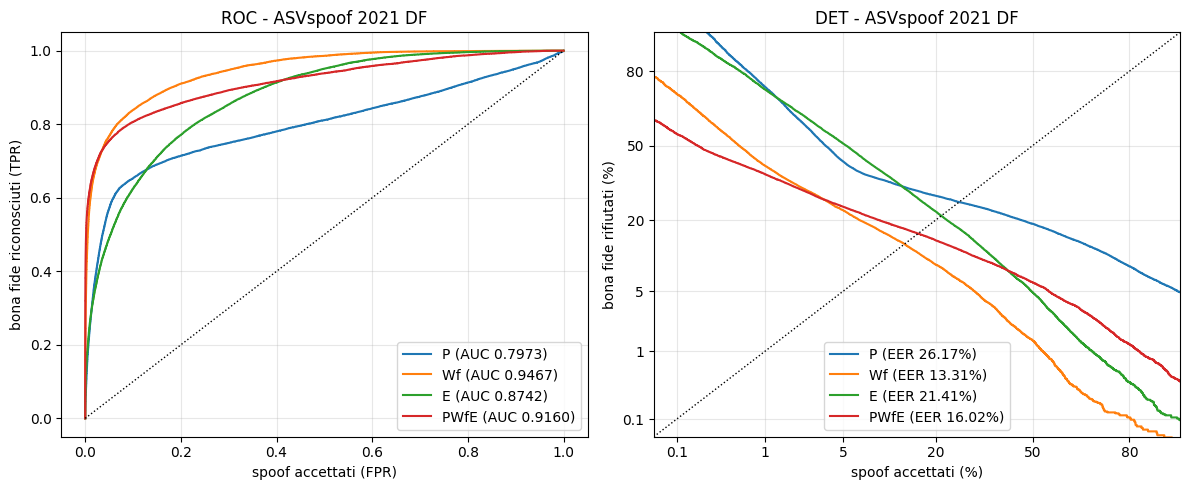

In [10]:

if FASE == "inferenza" and SCORES:
    from scipy.stats import norm
    _trapz = getattr(np, "trapezoid", None) or np.trapz
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for k, n in enumerate(NOMI):
        s_ = SCORES[n].astype(np.float64)
        frr, far, _ = asv_metrics.compute_det_curve(s_[Y == 1], s_[Y == 0])
        fpr, tpr = far[::-1], (1 - frr)[::-1]
        auc_sk = roc_auc_score(Y, s_)
        assert abs(float(_trapz(tpr, fpr)) - auc_sk) < 1e-3
        axes[0].plot(fpr, tpr, color=f"C{k}", label=f"{n} (AUC {auc_sk:.4f})")
        fa, fr = np.clip(far, 1e-4, 1 - 1e-4), np.clip(frr, 1e-4, 1 - 1e-4)
        axes[1].plot(norm.ppf(fa), norm.ppf(fr), color=f"C{k}",
                     label=f"{n} (EER {100 * compute_eer(Y, s_):.2f}%)")
    axes[0].plot([0, 1], [0, 1], "k:", lw=1)
    axes[0].set_xlabel("spoof accettati (FPR)"); axes[0].set_ylabel("bona fide riconosciuti (TPR)")
    axes[0].set_title("ROC - ASVspoof 2021 DF")
    ticks = np.array([0.001, 0.01, 0.05, 0.2, 0.5, 0.8])
    for setter in (axes[1].set_xticks, axes[1].set_yticks):
        setter(norm.ppf(ticks))
    axes[1].set_xticklabels([f"{100 * t:g}" for t in ticks])
    axes[1].set_yticklabels([f"{100 * t:g}" for t in ticks])
    lim = norm.ppf([0.0005, 0.9])
    axes[1].plot(lim, lim, "k:", lw=1); axes[1].set_xlim(lim); axes[1].set_ylim(lim)
    axes[1].set_xlabel("spoof accettati (%)"); axes[1].set_ylabel("bona fide rifiutati (%)")
    axes[1].set_title("DET - ASVspoof 2021 DF")
    for ax in axes:
        ax.grid(alpha=0.3); ax.legend()
    plt.tight_layout(); plt.savefig(OUT_DIR / "roc_det_df.png", dpi=120); plt.show()

In [11]:

if FASE == "inferenza" and SCORES:
    summary_out = {
        "dataset": "ASVspoof 2021 DF", "subsets": SUBSETS,
        "n_trials": int(len(index)), "n_bonafide": int(Y.sum()), "n_spoof": int((1 - Y).sum()),
        "trial_metadata": str(keys_path), "audio_dir": str(audio_root),
        "configurazioni": {n: str(CKPT[n]) for n in NOMI},
        "descrizione": {"P": "solo ramo prosodico, variante D (8 feature + delta)",
                        "Wf": "solo ramo Whisper a livello di file (media sui frame reali, 512)",
                        "E": "solo ramo ECAPA-TDNN a livello di file (192)",
                        "PWfE": "fusione tardiva dei tre rami"},
        "preprocessing": {"prosodia": str(PREPROC_PROSODIA), "standardizer": str(STANDARDIZER),
                          "nota": "statistiche dell'addestramento su ASVspoof 2019 LA, non ricalcolate sul DF"},
        "eer_globale_%": glob.round(4).reset_index().to_dict("records"),
        **{f"eer_per_{k}_%": v.reset_index().to_dict("records") for k, v in tabelle.items()},
        "eer_function": {"source": EVAL_METRICS_URL, "sha256": EVAL_METRICS_SHA256},
        "auc_function": "sklearn.metrics.roc_auc_score (metrica non ASVspoof, complementare)",
        "limiti": [
            "i quattro modelli non condividono il criterio di selezione del checkpoint: PWfE e' stato "
            "scelto sull'EER di sviluppo, P, Wf ed E sulla funzione di costo di sviluppo. Il confronto "
            "e' informativo e non controllato",
            "un solo seme di inizializzazione per ciascuna configurazione: nessuna stima della "
            "variabilita' di addestramento",
            "i modelli sono addestrati su audio non compresso con sei attacchi; il DF contiene nove "
            "condizioni di compressione, 110 attacchi e materiale proveniente da corpora diversi",
        ]}
    _ = (OUT_DIR / "summary_df.json").write_text(json.dumps(summary_out, indent=2, default=float))
    print("Output:", sorted(p.name for p in OUT_DIR.iterdir() if p.is_file()))

Output: ['classification_metrics.csv', 'eer_globale.csv', 'eer_per_attack.csv', 'eer_per_codec.csv', 'eer_per_source.csv', 'eer_per_vocoder.csv', 'eval_metrics.py', 'index_df.csv', 'metrics_globali.csv', 'roc_det_df.png', 'scores_df_E.npy', 'scores_df_P.npy', 'scores_df_PWfE.npy', 'scores_df_Wf.npy', 'summary_df.json']
